# Practice quiz: Gradient descent in practice


## Question 1

**Which of the following is a valid step used during feature scaling?**

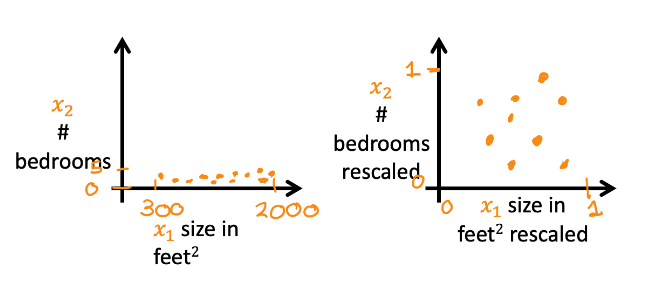

- Subtract the mean (average) from each value and then divide by the (max - min).
- Add the mean (average) from each value and and then divide by the (max - min).

### ✅ Correct Answer:

**Subtract the mean (average) from each value and then divide by the (max - min).**

### 📖 Explanation:

#### Why the first option is correct:

This describes **mean normalization**, a common feature scaling technique. The formula is:

$$x_{norm} = \frac{x - \mu}{max - min}$$

Where:
- $x$ is the original feature value
- $\mu$ is the mean (average) of the feature
- $max$ and $min$ are the maximum and minimum values of the feature

**Why this works:**
- Subtracting the mean centers the data around zero
- Dividing by the range scales the data to a consistent interval (typically between -0.5 and 0.5)
- This ensures all features contribute equally to the model, preventing features with larger ranges from dominating the learning process

#### Why the second option is incorrect:

Adding the mean would shift the data away from zero, not center it. For example, if your original data ranges from 300 to 2000 with a mean of 600, adding the mean would give you values from 900 to 2600, making the range even larger! This defeats the purpose of feature scaling, which is to bring all features into comparable ranges.

### 🌍 Real-World Example:

**Mean Normalization in Action:**

Imagine you're analyzing customer data for an e-commerce business:
- **Feature A:** Annual income (range: \$20,000 - \$200,000, mean: \$60,000)
- **Feature B:** Number of purchases per year (range: 1-50, mean: 15)

Without scaling, income would dominate the model simply because its numbers are larger. After mean normalization:
- Income of \$100,000 becomes: (100,000 - 60,000) / (200,000 - 20,000) = 40,000 / 180,000 = 0.22
- Purchase count of 30 becomes: (30 - 15) / (50 - 1) = 15 / 49 = 0.31

Now both features have comparable ranges, and the model can learn the true importance of each feature without being biased by their original scales.

---



## Question 2

**Of the circumstances below, for which one is feature scaling particularly helpful?**

- [ ] Feature scaling is helpful when one feature is much larger (or smaller) than another feature.
- [ ] Feature scaling is helpful when all the features in the original data (before scaling is applied) range from 0 to 1.

### ✅ Correct Answer:

**Feature scaling is helpful when one feature is much larger (or smaller) than another feature.**

### 📖 Explanation:

#### Why the first option is correct:

Feature scaling is designed precisely to address the problem of features with **different magnitudes**. When features have vastly different ranges:
- Features with larger values can dominate the cost function
- Gradient descent becomes inefficient, oscillating back and forth
- The algorithm takes much longer to converge

**The core problem:** If one feature ranges from 300-2000 and another from 0-5, small changes to the first feature's weight cause huge changes in predictions, while large changes to the second feature's weight barely affect predictions. This creates elongated contour plots where gradient descent struggles.

#### Why the second option is incorrect:

If all features already range from 0 to 1, they are already on comparable scales! Feature scaling would be unnecessary because:
- No feature dominates others due to magnitude
- Gradient descent can already take efficient paths
- The contour plots would already be roughly circular

This situation represents an **ideal starting point** - no scaling needed!

### 🌍 Real-World Example:

**When Feature Scaling Saves the Day:**

A real estate company is building a model to predict house prices with these features:
- **Square footage:** 500 - 5,000 sq ft (range: 4,500)
- **Number of bedrooms:** 1 - 6 (range: 5)
- **Year built:** 1900 - 2023 (range: 123)
- **Distance to city center:** 0.1 - 50 miles (range: 49.9)

**Without scaling:** Square footage would dominate because its range (4,500) is 900 times larger than bedrooms' range (5). The model would act as if square footage is 900 times more important than bedrooms!

**With scaling:** After applying z-score normalization, all features have zero mean and unit variance. Now the model can objectively learn the true importance of each feature based on the data, not their original measurement units.

---



## Question 3

**Suppose a friend ran gradient descent three separate times with three choices of the learning rate α and plotted the learning curves for each (cost J for each iteration).**

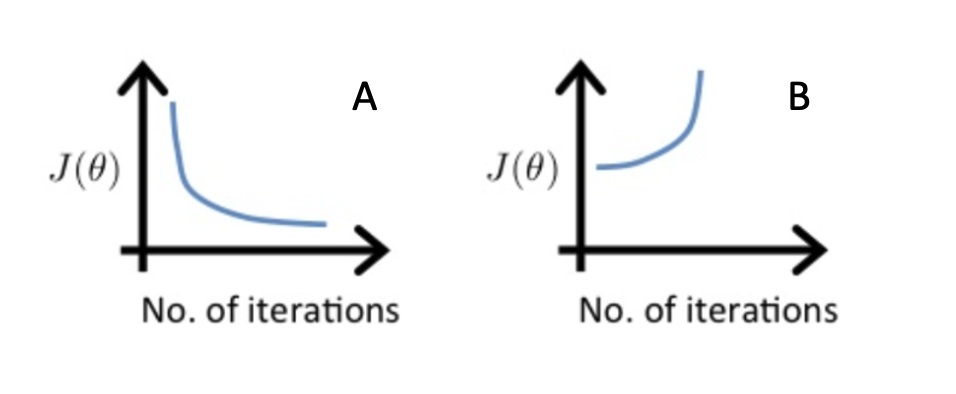

**For which case, A or B, was the learning rate α likely too large?**

- [ ] case A only
- [ ] case B only
- [ ] Both Cases A and B
- [ ] Neither Case A nor B

### ✅ Correct Answer:

**case B only**

### 📖 Explanation:

#### Understanding Learning Curves:

A learning curve plots the **cost function value** (vertical axis) against the **number of iterations** (horizontal axis) of gradient descent. This visualization helps diagnose how well gradient descent is performing.

#### Case A Analysis (Healthy Convergence):
- Cost decreases steadily with each iteration
- The curve is smooth and monotonically decreasing
- Eventually flattens out as it approaches the minimum
- This is the **ideal behavior** - gradient descent is working correctly

#### Case B Analysis (Learning Rate Too Large):
- Cost oscillates wildly, sometimes going up, sometimes down
- The curve is jagged and doesn't consistently decrease
- May even increase above previous values
- This indicates the learning rate α is too large, causing gradient descent to **overshoot** the minimum repeatedly

#### Why oscillation happens with large α:
1. The algorithm takes steps that are too large
2. It jumps over the minimum to the other side
3. The next step overshoots back in the opposite direction
4. This creates a bouncing effect that never settles at the minimum

### 🌍 Real-World Example:

**The "Boulder Rolling Down a Hill" Analogy:**

Imagine you're trying to roll a boulder down a hill to find the lowest point (the minimum):

- **Appropriate learning rate (Case A):** You give the boulder gentle pushes. It rolls smoothly downhill, gradually slowing as it approaches the valley floor, eventually settling at the bottom.

- **Learning rate too large (Case B):** You give the boulder a massive shove. It rockets down the hill, flies past the valley floor, up the opposite side, then rolls back down, up again, oscillating back and forth. It might never settle at the bottom!

- **Learning rate too small:** You barely nudge the boulder. It moves inch by inch, taking forever to reach the bottom. You'll eventually get there, but it will take thousands of tiny pushes.

**In machine learning terms:** The boulder's position represents your model parameters, the hill shape is your cost function, and your pushes are the learning rate α multiplied by the gradient.



---

## Question 4

**True/False? With polynomial regression, the predicted values f_w,b(x) does not necessarily have to be a straight line (or linear) function of the input feature x.**

- [ ] True
- [ ] False

### ✅ Correct Answer:

**True**

### 📖 Explanation:

#### Why the statement is true:

**Polynomial regression** extends linear regression by creating new features that are powers of the original feature. For example:

- **Simple linear regression:** $f_{w,b}(x) = wx + b$ (a straight line)
- **Quadratic regression:** $f_{w,b}(x) = w_1x + w_2x^2 + b$ (a parabola)
- **Cubic regression:** $f_{w,b}(x) = w_1x + w_2x^2 + w_3x^3 + b$ (an S-shaped curve)

Despite creating curved relationships with respect to the original feature **x**, polynomial regression is still considered **linear regression** because it's linear in the parameters. The "linear" in linear regression refers to the parameters ($w$'s and $b$), not the features!

#### Mathematical insight:

In polynomial regression, we're still solving for parameters in an equation of the form:
$$f_{\vec{w},b}(\vec{x}) = w_1x_1 + w_2x_2 + w_3x_3 + ... + b$$

The only difference is that $x_2 = x_1^2$, $x_3 = x_1^3$, etc. So while the relationship between $x$ and the prediction is non-linear, the relationship between the **parameters** and the prediction is linear.

### 🌍 Real-World Example:

**Modeling Plant Growth:**

A biologist wants to model how a plant's height changes over time:

- **Linear model:** Height = $w \times \text{time} + b$
  - This assumes constant growth rate - plants grow the same amount each day
  - This rarely matches reality; plants grow faster in ideal conditions, slower in drought

- **Polynomial model:** Height = $w_1 \times \text{time} + w_2 \times \text{time}^2 + b$
  - The $time^2$ term captures accelerating or decelerating growth
  - If $w_2$ is positive, growth accelerates (plant hits its stride)
  - If $w_2$ is negative, growth decelerates (plant reaches maturity)

- **Cubic model:** Height = $w_1t + w_2t^2 + w_3t^3 + b$
  - Can model S-shaped growth curves (slow start, rapid middle growth, slow finish)
  - Perfect for biological growth, product adoption cycles, or epidemic spread

The biologist can now capture the **non-linear** reality of plant growth while still using the mathematical framework of linear regression!

---

## Question 5

**You are helping a grocery store predict its revenue, and have data on its items sold per week, and price per item. What could be a useful engineered feature?**

- [ ] For each product, calculate the number of items sold times price per item.
- [ ] For each product, calculate the number of items sold divided by the price per item.

### ✅ Correct Answer:

**For each product, calculate the number of items sold times price per item.**

### 📖 Explanation:

#### Why the first option is correct:

**Revenue = Quantity × Price**

This is a fundamental business equation! By multiplying items sold by price per item, you're directly calculating the **revenue generated by each product**. This is an example of **feature engineering** - creating a new, more informative feature by combining existing ones.

**Why this is valuable:**
- Revenue is often more predictive of overall store performance than quantity or price alone
- A product with high quantity but low price might contribute less than a medium-quantity, high-price item
- The engineered feature captures the **interaction effect** between quantity and price

#### Why the second option is incorrect:

**Quantity ÷ Price** doesn't represent any meaningful business metric:
- This would give you something like "items per dollar" or "purchasing efficiency"
- While this might be useful in some contexts (e.g., measuring price sensitivity), it's not directly predicting revenue
- For revenue prediction, multiplication is the correct operation

### 🌍 Real-World Example:

**Grocery Store Revenue Prediction:**

A grocery store has data on thousands of products:

| Product | Items Sold (weekly) | Price per Item | Revenue (Engineered Feature) |
|---------|---------------------|----------------|------------------------------|
| Bread   | 500                 | $2.50          | $1,250                       |
| Steak   | 50                  | $15.00         | $750                         |
| Soda    | 800                 | $1.25          | $1,000                       |
| Caviar  | 2                   | $100.00        | $200                         |

**Without engineered feature:** The model sees bread has high sales (500) and low price (\$2.50), caviar has low sales (2) and high price (\$100). It might incorrectly learn that "sales" and "price" are equally important for all products.

**With engineered feature (Revenue):** The model now understands that:
- Bread contributes \$1,250 to total revenue
- Steak contributes only \$750 despite its high price
- Soda contributes \$1,000 with moderate sales and price
- Caviar contributes just \$200 despite its luxury status

This allows the store to:
1. Identify true revenue drivers (not just high-volume or high-price items)
2. Make better inventory decisions
3. Predict total store revenue more accurately by summing product revenues

**Other powerful engineered features for retail:**
- **Profit margin:** Price - Cost (if cost data is available)
- **Revenue per square foot:** Revenue / Shelf space allocated
- **Seasonal indicators:** Whether the week contains a holiday
- **Promotion flag:** Whether the item was on sale that week

---

## 📊 Summary Table

| Question | Topic | Correct Answer | Key Concept |
|----------|-------|----------------|-------------|
| 1 | Feature Scaling | Subtract mean, divide by (max-min) | Mean normalization centers and scales data |
| 2 | When to Scale | When features have different magnitudes | Prevents features with larger ranges from dominating |
| 3 | Learning Curves | Case B only | Oscillating cost indicates learning rate too large |
| 4 | Polynomial Regression | True | Creates curved relationships while remaining linear in parameters |
| 5 | Feature Engineering | Quantity × Price | Creates meaningful interactions between existing features |

---

## 🔑 Key Takeaways for Beginners

1. **Feature Scaling** is like converting different currencies to a common unit - it lets your model treat all features fairly

2. **Learning Curves** are your diagnostic tool - they tell you if gradient descent is working correctly or if you need to adjust your learning rate

3. **Polynomial Regression** lets you fit curves while keeping the simplicity of linear models - it's the best of both worlds!

4. **Feature Engineering** is where domain expertise shines - combining features in meaningful ways often beats complex algorithms

5. **Always ask "Why?"** when creating features: Does this combination make business sense? Will it help predict my target?